### Predictive Analysis — Healthcare Appointment Wait-Days Prediction

`03_no_show_predictive_modeling.ipynb` tackled the first business problem, predicting **No-show risk**
 and found only weak predictive signal (best tuned ROC-AUC 0.553), which the notebook
attributed to the small dataset (only 56 No-show cases out of 500).

This notebook tackles the project's **second business problem - waiting time**, but frames it
as a **regression** problem instead of classification:

> **Business question:** Given information available at the time a patient books an
> appointment, can we predict how many days (`wait_days`) they will have to wait?

Unlike No-show risk (a yes/no outcome), `wait_days` is a **continuous number**, so this
notebook trains and compares regression models — Linear Regression, Ridge, Decision Tree,
Random Forest, and Gradient Boosting, evaluated with RMSE, MAE, and R², and tuned via
cross-validated `GridSearchCV`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## Data Preprocessing
### 1. Load the Clean Dataset

Same source as `03_no_show_predictive_modeling.ipynb` — **`data/appointments_clean.csv`**.

In [2]:
df = pd.read_csv('../data/appointments_clean.csv', parse_dates=['appointment_date'])

print("=== Dataset Overview ===")
print(f"Rows, Columns : {df.shape}")
print(f"Date Range    : {df['appointment_date'].min().date()} → {df['appointment_date'].max().date()}\n")

print("=== Columns & Types ===")
print(df.dtypes)

df.head()

=== Dataset Overview ===
Rows, Columns : (500, 12)
Date Range    : 2023-01-02 → 2024-12-26

=== Columns & Types ===
patient_age                      int64
patient_gender                  object
division                        object
doctor_specialty                object
appointment_status              object
consultation_fee_bdt             int64
wait_days                        int64
appointment_date        datetime64[ns]
age_group                       object
month                            int64
year                             int64
month_name                      object
dtype: object


,patient_age,patient_gender,division,doctor_specialty,appointment_status,consultation_fee_bdt,wait_days,appointment_date,age_group,month,year,month_name
0,56,Female,Chattogram,Gynecologist,Completed,914,4,2023-11-19,Senior (56+),11,2023,Nov
1,19,Male,Barishal,Cardiologist,Completed,1546,6,2024-06-07,Young Adult (18-35),6,2024,Jun
2,76,Female,Dhaka,Pediatrician,Completed,725,1,2023-02-27,Senior (56+),2,2023,Feb
3,65,Male,Chattogram,Cardiologist,Completed,1492,20,2024-03-17,Senior (56+),3,2024,Mar
4,25,Male,Dhaka,Orthopedic,Cancelled,1331,16,2023-04-06,Young Adult (18-35),4,2023,Apr


### 2. Feature Engineering

Here, **`wait_days` is the target**, and `appointment_date` is effectively
`booking_date + wait_days`. Using calendar features derived from `appointment_date` as
predictors of `wait_days` would mean the target leaks into its own predictors — those
features aren't actually knowable at the moment a patient books.

The fix: reconstruct the **`booking_date`**, the day the patient actually made the booking,
and derive the same calendar signals (quarter, month, day of week, weekday/weekend) from
*that* date instead. `booking_date` is knowable the instant a patient books, so features
built from it are genuinely available before `wait_days` is decided — no leakage.

```
booking_date = appointment_date − wait_days
```

In [3]:
BD_WEEKEND_DAYS = {'Friday', 'Saturday'}

df['booking_date'] = df['appointment_date'] - pd.to_timedelta(df['wait_days'], unit='D')

df['booking_quarter'] = 'Q' + df['booking_date'].dt.quarter.astype(str)
df['booking_month_name'] = df['booking_date'].dt.month_name().str[:3]
df['booking_day_of_week'] = df['booking_date'].dt.day_name()
df['booking_day_type'] = np.where(df['booking_day_of_week'].isin(BD_WEEKEND_DAYS), 'Weekend', 'Weekday')

print("=== Sample of derived booking_date and engineered features ===")
df[['appointment_date', 'wait_days', 'booking_date', 'booking_quarter',
    'booking_month_name', 'booking_day_of_week', 'booking_day_type']].head(8)

=== Sample of derived booking_date and engineered features ===


,appointment_date,wait_days,booking_date,booking_quarter,booking_month_name,booking_day_of_week,booking_day_type
0,2023-11-19,4,2023-11-15,Q4,Nov,Wednesday,Weekday
1,2024-06-07,6,2024-06-01,Q2,Jun,Saturday,Weekend
2,2023-02-27,1,2023-02-26,Q1,Feb,Sunday,Weekday
3,2024-03-17,20,2024-02-26,Q1,Feb,Monday,Weekday
4,2023-04-06,16,2023-03-21,Q1,Mar,Tuesday,Weekday
5,2023-11-19,15,2023-11-04,Q4,Nov,Saturday,Weekend
6,2024-05-24,17,2024-05-07,Q2,May,Tuesday,Weekday
7,2023-09-06,8,2023-08-29,Q3,Aug,Tuesday,Weekday


### 3. Correlation Check and Other Observation

Before modeling, a quick correlation check with `wait_days`. `01_analysis.ipynb` already flagged that
correlations between age, fee, wait time and appointment timing were all under ~0.10 for the
full dataset; the same check is repeated here against the exact feature set going into this
model.

In [4]:
print("=== Correlation with wait_days ===")
print(f"patient_age            : {df['wait_days'].corr(df['patient_age']):.4f}")
print(f"consultation_fee_bdt   : {df['wait_days'].corr(df['consultation_fee_bdt']):.4f}")

print("\n=== Mean wait_days by division ===")
print(df.groupby('division')['wait_days'].mean().sort_values().round(2))

print("\n=== Mean wait_days by specialty ===")
print(df.groupby('doctor_specialty')['wait_days'].mean().sort_values().round(2))

print(f"\nOverall mean wait_days: {df['wait_days'].mean():.2f} | std: {df['wait_days'].std():.2f}")

=== Correlation with wait_days ===
patient_age            : -0.0007
consultation_fee_bdt   : -0.0476

=== Mean wait_days by division ===
division
Rangpur        7.70
Barishal       9.27
Chattogram    10.38
Dhaka         10.51
Khulna        10.63
Rajshahi      10.95
Sylhet        11.35
Mymensingh    11.44
Name: wait_days, dtype: float64

=== Mean wait_days by specialty ===
doctor_specialty
Cardiologist          8.98
Pediatrician          9.29
Dermatologist        10.49
Orthopedic           11.48
Gynecologist         11.55
General Physician    11.56
Name: wait_days, dtype: float64

Overall mean wait_days: 10.50 | std: 5.88


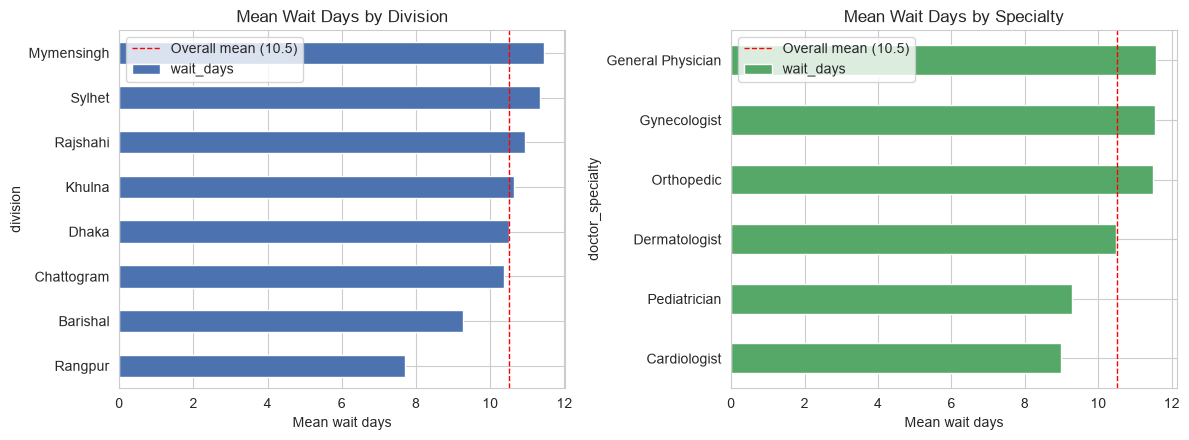

In [5]:
overall_mean = df['wait_days'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

div_means = df.groupby('division')['wait_days'].mean().sort_values()
div_means.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].axvline(overall_mean, color='red', linestyle='--', linewidth=1, label=f'Overall mean ({overall_mean:.1f})')
axes[0].set_title('Mean Wait Days by Division')
axes[0].set_xlabel('Mean wait days')
axes[0].legend()

spec_means = df.groupby('doctor_specialty')['wait_days'].mean().sort_values()
spec_means.plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].axvline(overall_mean, color='red', linestyle='--', linewidth=1, label=f'Overall mean ({overall_mean:.1f})')
axes[1].set_title('Mean Wait Days by Specialty')
axes[1].set_xlabel('Mean wait days')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4. Target Distribution

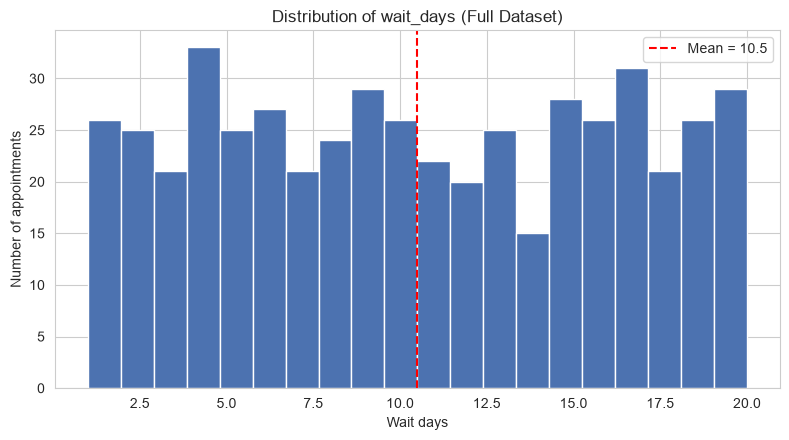

count    500.00
mean      10.50
std        5.88
min        1.00
25%        5.00
50%       10.00
75%       16.00
max       20.00
Name: wait_days, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
n, bins, patches = ax.hist(df['wait_days'], bins=20, color='#4C72B0', edgecolor='white')
ax.axvline(df['wait_days'].mean(), color='red', linestyle='--', label=f"Mean = {df['wait_days'].mean():.1f}")
ax.set_xlabel('Wait days')
ax.set_ylabel('Number of appointments')
ax.set_title('Distribution of wait_days (Full Dataset)')
ax.legend()
plt.tight_layout()
plt.show()

print(df['wait_days'].describe().round(2))

### 5. Feature Selection

| Column | Use as a feature? | Reason |
|---|---|---|
| `wait_days` | ❌ Target, not a feature | What will be predicted. |
| `appointment_status` | ❌ **Excluded** | Only known *after* the appointment happens (Completed/Cancelled/No-show) — not available before `wait_days` is assigned. |
| `appointment_date` (raw) | ❌ Excluded | Downstream of `wait_days` (`booking_date + wait_days`). Replaced by `booking_date`-derived features. |
| `booking_date` (raw) | ❌ Excluded | Replaced by the engineered calendar features below. |
| `booking_year` | ❌ Excluded | Same reasoning as excluding `year` in `03_predictive_modeling.ipynb` — future bookings (2025, 2026, ...) carry year values never seen in training. |
| `consultation_fee_bdt` | ❌ **Excluded** | near 1:1 stand-in for `doctor_specialty` (fixed fee bands per specialty), so redundant. |
| `age_group` | ❌ Excluded | Binned version of `patient_age`; keeping both is redundant. |
| `month`, `year` (original columns) | ❌ Excluded | Describe `appointment_date`, not `booking_date` — replaced by the engineered `booking_*` features. |
| `patient_age` | ✅ Included | Known at booking time. |
| `patient_gender` | ✅ Included | Known at booking time. |
| `division` | ✅ Included | Known at booking time. |
| `doctor_specialty` | ✅ Included | Known at booking time. |
| `booking_quarter`, `booking_month_name`, `booking_day_of_week`, `booking_day_type` | ✅ Included | Derived from `booking_date`, which is known the instant the patient books. |

In [7]:
categorical_features = [
    'patient_gender', 'division', 'doctor_specialty',
    'booking_quarter', 'booking_month_name', 'booking_day_of_week', 'booking_day_type'
]
numerical_features = ['patient_age']

feature_cols = categorical_features + numerical_features

X = df[feature_cols]
y = df['wait_days']

print("Final feature set:")
print(f"  Categorical ({len(categorical_features)}): {categorical_features}")
print(f"  Numerical   ({len(numerical_features)}): {numerical_features}")
print(f"\nX shape: {X.shape}   y shape: {y.shape}")

Final feature set:
  Categorical (7): ['patient_gender', 'division', 'doctor_specialty', 'booking_quarter', 'booking_month_name', 'booking_day_of_week', 'booking_day_type']
  Numerical   (1): ['patient_age']

X shape: (500, 8)   y shape: (500,)


### 6. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train set: {X_train.shape[0]} rows  |  Test set: {X_test.shape[0]} rows")
print(f"\nTrain wait_days — mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"Test  wait_days — mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")

Train set: 400 rows  |  Test set: 100 rows

Train wait_days — mean: 10.41, std: 5.83
Test  wait_days — mean: 10.84, std: 6.10


### 7. Preprocessing + Model Pipelines

`OneHotEncoder` for categoricals, `StandardScaler` for
`patient_age`.

**Six models compared:**

* **Dummy (Mean)** — a naive baseline that always predicts the training mean, regardless of
  input. Not a real model.
* **Linear Regression** — interpretable baseline.
* **Ridge** — Linear Regression with L2 regularization; added alongside plain Linear
  Regression since one-hot encoding produces many correlated columns, and Ridge handles that
  more gracefully.
* **Decision Tree, Random Forest, Gradient Boosting** — three non-linear model families of
  increasing complexity, plus Gradient Boosting for a broader comparison.

In [9]:
def make_pipeline(regressor):
    preprocessor = ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features),
    ])
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor),
    ])

models = {
    'Dummy (Mean)':       DummyRegressor(strategy='mean'),
    'Linear Regression':  LinearRegression(),
    'Ridge':              Ridge(random_state=42),
    'Decision Tree':      DecisionTreeRegressor(random_state=42),
    'Random Forest':      RandomForestRegressor(random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(random_state=42),
}

make_pipeline(models['Linear Regression'])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If

## Model Training — Baseline Evaluation

**Metrics used:**

* **RMSE** (Root Mean Squared Error) — average prediction error in days, penalizing larger
  errors more heavily. Lower is better.
* **MAE** (Mean Absolute Error) — average prediction error in days, treating all errors
  equally. Lower is better.
* **R²** — proportion of variance in `wait_days` explained by the model. 1.0 is a perfect fit,
  0.0 means no better than predicting the naive mean, and **negative values mean the model
  is worse than naive mean prediction**.

In [22]:
baseline_results = []
fitted_models = {}

for name, regressor in models.items():
    pipe = make_pipeline(regressor)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    baseline_results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    fitted_models[name] = pipe

baseline_df = pd.DataFrame(baseline_results)
print("Baseline models trained.")
display(baseline_df.sort_values('R2', ascending=False).reset_index(drop=True).round(4))

Baseline models trained.


,Model,RMSE,MAE,R2
0,Dummy (Mean),6.0807,5.4068,-0.0049
1,Ridge,6.2613,5.4228,-0.0655
2,Linear Regression,6.2656,5.4226,-0.0670
3,Gradient Boosting,6.3355,5.5238,-0.0909
4,Random Forest,6.4469,5.6323,-0.1296
5,Decision Tree,9.1121,7.6500,-1.2566


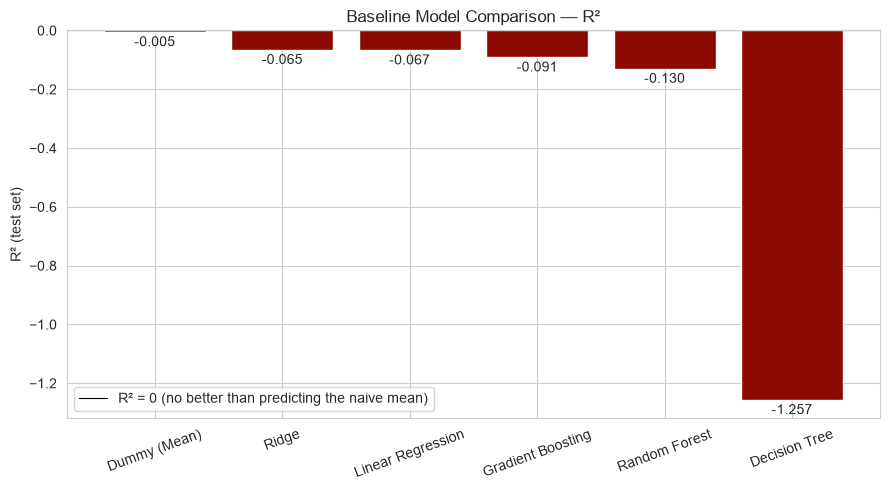

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = baseline_df.sort_values('R2', ascending=False)
colors = ['#8C0900' if r < 0 else '#4C72B0' for r in plot_df['R2']]
bars = ax.bar(plot_df['Model'], plot_df['R2'], color=colors)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.axhline(0, color='black', linewidth=0.8, label='R² = 0 (no better than predicting the naive mean)')
ax.set_ylabel('R² (test set)')
ax.set_title('Baseline Model Comparison — R²')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** All fitted models had negative R² scores at baseline, meaning they performed worse on the test set than the simple Dummy Mean baseline. Decision Tree performed the worst (R² ≈ −1.26), suggesting that it overfit the training data and failed to generalize well. Overall, the results, along with the weak correlations and flat group averages, suggest that the current features have limited predictive signal for `wait_days`.

### Predicted vs. Actual — Best Baseline Model

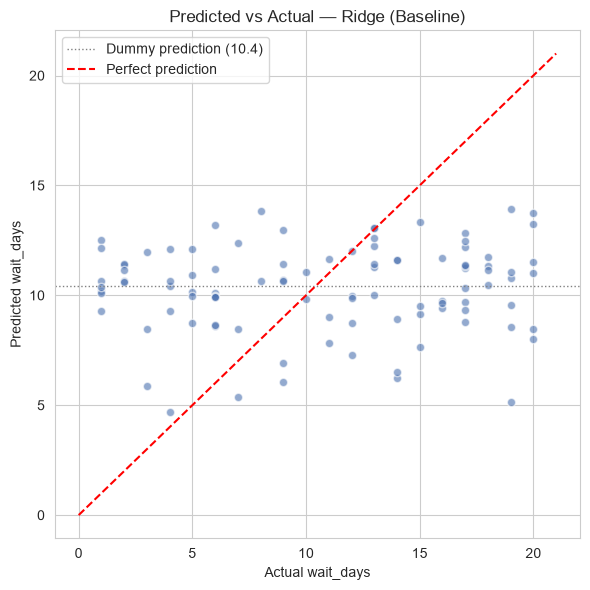

Best real (non-Dummy) baseline model by R²: Ridge


In [ ]:
real_models_df = baseline_df[baseline_df['Model'] != 'Dummy (Mean)']
best_baseline_name = real_models_df.loc[real_models_df['R2'].idxmax(), 'Model']
best_baseline_pipe = fitted_models[best_baseline_name]
pred_best_baseline = best_baseline_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_best_baseline, alpha=0.6, color='#4C72B0', edgecolor='white')
ax.axhline(y_train.mean(), color='gray', linestyle=':', linewidth=1, label=f'Dummy prediction ({y_train.mean():.1f})')
lims = [min(y_test.min(), pred_best_baseline.min()) - 1, max(y_test.max(), pred_best_baseline.max()) + 1]
ax.plot(lims, lims, linestyle='--', color='red', label='Perfect prediction')
ax.set_xlabel('Actual wait_days')
ax.set_ylabel('Predicted wait_days')
ax.set_title(f'Predicted vs Actual — {best_baseline_name} (Baseline)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best real (non-Dummy) baseline model by R²: {best_baseline_name}")

The best real model's predictions scatter loosely around the Dummy's flat mean-line
rather than tracking the diagonal, and the R² table above already shows every real model
sits *below* the Dummy baseline — visual and numeric confirmation that none of them are
capturing real structure in `wait_days` beyond what guessing the average already gives.

## Model Improvement — Hyperparameter Tuning

Used GridSearchCV with cross-validation to find better hyperparameters for the models and improve their performance. R² was used as the scoring metric so that the tuning process focused on the same metric used to evaluate the final models.

In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [15]:
# Ridge — GridSearchCV
param_grid_ridge = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
}

grid_ridge = GridSearchCV(make_pipeline(Ridge(random_state=42)), param_grid_ridge, scoring='r2', cv=cv, n_jobs=-1)
grid_ridge.fit(X_train, y_train)

ridge_tuned = grid_ridge.best_estimator_
pred_ridge_tuned = ridge_tuned.predict(X_test)
r2_ridge_tuned = r2_score(y_test, pred_ridge_tuned)
rmse_ridge_tuned = np.sqrt(mean_squared_error(y_test, pred_ridge_tuned))

print("=== Ridge Tuning Results ===")
print(f"Before Tuning R²: {baseline_df.loc[baseline_df.Model=='Ridge','R2'].values[0]:.4f}")
print(f"After Tuning R²:  {r2_ridge_tuned:.4f}")
print(f"Best Parameters:  {grid_ridge.best_params_}")

=== Ridge Tuning Results ===
Before Tuning R²: -0.0655
After Tuning R²:  -0.0192
Best Parameters:  {'regressor__alpha': 100.0}


In [16]:
# Decision Tree — GridSearchCV
param_grid_dt = {
    'regressor__max_depth': [3, 5, 6, 7, 8, 10, None],
    'regressor__min_samples_leaf': [2, 3, 5, 7, 10],
    'regressor__min_samples_split': [2, 5, 10],
}

grid_dt = GridSearchCV(make_pipeline(DecisionTreeRegressor(random_state=42)), param_grid_dt, scoring='r2', cv=cv, n_jobs=-1)
grid_dt.fit(X_train, y_train)

dt_tuned = grid_dt.best_estimator_
pred_dt_tuned = dt_tuned.predict(X_test)
r2_dt_tuned = r2_score(y_test, pred_dt_tuned)
rmse_dt_tuned = np.sqrt(mean_squared_error(y_test, pred_dt_tuned))

print("=== Decision Tree Tuning Results ===")
print(f"Before Tuning R²: {baseline_df.loc[baseline_df.Model=='Decision Tree','R2'].values[0]:.4f}")
print(f"After Tuning R²:  {r2_dt_tuned:.4f}")
print(f"Best Parameters:  {grid_dt.best_params_}")

=== Decision Tree Tuning Results ===
Before Tuning R²: -1.2566
After Tuning R²:  -0.0615
Best Parameters:  {'regressor__max_depth': 3, 'regressor__min_samples_leaf': 10, 'regressor__min_samples_split': 2}


In [17]:
# Random Forest — GridSearchCV
param_grid_rf = {
    'regressor__n_estimators': [80, 90, 100, 150],
    'regressor__max_depth': [4, 6, 8, None],
    'regressor__min_samples_leaf': [1, 2, 3, 5],
}

grid_rf = GridSearchCV(make_pipeline(RandomForestRegressor(random_state=42)), param_grid_rf, scoring='r2', cv=cv, n_jobs=-1)
grid_rf.fit(X_train, y_train)

rf_tuned = grid_rf.best_estimator_
pred_rf_tuned = rf_tuned.predict(X_test)
r2_rf_tuned = r2_score(y_test, pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, pred_rf_tuned))

print("=== Random Forest Tuning Results ===")
print(f"Before Tuning R²: {baseline_df.loc[baseline_df.Model=='Random Forest','R2'].values[0]:.4f}")
print(f"After Tuning R²:  {r2_rf_tuned:.4f}")
print(f"Best Parameters:  {grid_rf.best_params_}")

=== Random Forest Tuning Results ===
Before Tuning R²: -0.1296
After Tuning R²:  -0.0421
Best Parameters:  {'regressor__max_depth': 4, 'regressor__min_samples_leaf': 5, 'regressor__n_estimators': 80}


In [18]:
# Gradient Boosting — GridSearchCV
param_grid_gb = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [2, 3, 4],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
}

grid_gb = GridSearchCV(make_pipeline(GradientBoostingRegressor(random_state=42)), param_grid_gb, scoring='r2', cv=cv, n_jobs=-1)
grid_gb.fit(X_train, y_train)

gb_tuned = grid_gb.best_estimator_
pred_gb_tuned = gb_tuned.predict(X_test)
r2_gb_tuned = r2_score(y_test, pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, pred_gb_tuned))

print("=== Gradient Boosting Tuning Results ===")
print(f"Before Tuning R²: {baseline_df.loc[baseline_df.Model=='Gradient Boosting','R2'].values[0]:.4f}")
print(f"After Tuning R²:  {r2_gb_tuned:.4f}")
print(f"Best Parameters:  {grid_gb.best_params_}")

=== Gradient Boosting Tuning Results ===
Before Tuning R²: -0.0909
After Tuning R²:  -0.0073
Best Parameters:  {'regressor__learning_rate': 0.01, 'regressor__max_depth': 2, 'regressor__n_estimators': 100}


**Note on Linear Regression:** plain `LinearRegression` has no hyperparameters to tune, it's carried forward unchanged
from the baseline table below for comparison.

In [25]:
dummy_rmse = baseline_df.loc[baseline_df.Model=='Dummy (Mean)','RMSE'].values[0]
dummy_r2 = baseline_df.loc[baseline_df.Model=='Dummy (Mean)','R2'].values[0]
lr_rmse = baseline_df.loc[baseline_df.Model=='Linear Regression','RMSE'].values[0]
lr_r2 = baseline_df.loc[baseline_df.Model=='Linear Regression','R2'].values[0]

tuned_comparison = pd.DataFrame({
    'Model': ['Dummy (Mean)', 'Linear Regression', 'Ridge', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Baseline R2': [dummy_r2, lr_r2,
                    baseline_df.loc[baseline_df.Model=='Ridge','R2'].values[0],
                    baseline_df.loc[baseline_df.Model=='Decision Tree','R2'].values[0],
                    baseline_df.loc[baseline_df.Model=='Random Forest','R2'].values[0],
                    baseline_df.loc[baseline_df.Model=='Gradient Boosting','R2'].values[0]],
    'Baseline RMSE': [dummy_rmse, lr_rmse,
                       baseline_df.loc[baseline_df.Model=='Ridge','RMSE'].values[0],
                       baseline_df.loc[baseline_df.Model=='Decision Tree','RMSE'].values[0],
                       baseline_df.loc[baseline_df.Model=='Random Forest','RMSE'].values[0],
                       baseline_df.loc[baseline_df.Model=='Gradient Boosting','RMSE'].values[0]],
    'Tuned R2': [dummy_r2, lr_r2, r2_ridge_tuned, r2_dt_tuned, r2_rf_tuned, r2_gb_tuned],
    'Tuned RMSE': [dummy_rmse, lr_rmse, rmse_ridge_tuned, rmse_dt_tuned, rmse_rf_tuned, rmse_gb_tuned],
})
tuned_comparison['Beats Naive Baseline?'] = tuned_comparison['Tuned R2'] > dummy_r2
tuned_comparison.round(4)

,Model,Baseline R2,Baseline RMSE,Tuned R2,Tuned RMSE,Beats Naive Baseline?
0,Dummy (Mean),-0.0049,6.0807,-0.0049,6.0807,False
1,Linear Regression,-0.0670,6.2656,-0.0670,6.2656,False
2,Ridge,-0.0655,6.2613,-0.0192,6.1239,False
3,Decision Tree,-1.2566,9.1121,-0.0615,6.2495,False
4,Random Forest,-0.1296,6.4469,-0.0421,6.1922,False
5,Gradient Boosting,-0.0909,6.3355,-0.0073,6.0879,False


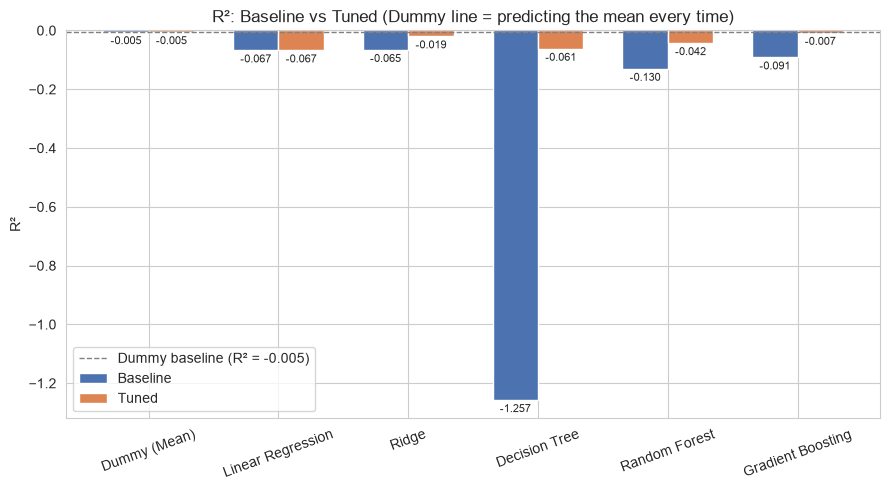

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(tuned_comparison))
width = 0.35

bars_base = ax.bar(x - width/2, tuned_comparison['Baseline R2'], width, label='Baseline', color='#4C72B0')
bars_tuned = ax.bar(x + width/2, tuned_comparison['Tuned R2'], width, label='Tuned', color='#DD8452')
ax.axhline(dummy_r2, color='gray', linestyle='--', linewidth=1, label=f'Dummy baseline (R² = {dummy_r2:.3f})')

ax.bar_label(bars_base, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars_tuned, fmt='%.3f', padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(tuned_comparison['Model'], rotation=20)
ax.set_ylabel('R²')
ax.set_title('R²: Baseline vs Tuned (Dummy line = predicting the mean every time)')
ax.legend()
plt.tight_layout()
plt.show()

## Final Model Selection

After tuning, all models performed closer to the Dummy Mean baseline, and the severe overfitting seen in the untuned Decision Tree was reduced. However, **none of the tuned models outperformed the Dummy Mean baseline** in terms of R².

**Gradient Boosting** performed closest to the baseline after tuning, but its R² was still negative. This suggests that the current features provide very limited information for predicting `wait_days`.

Overall, the results indicate that the available features, patient demographics, division, specialty, and booking-time information are not sufficient to make reliable waiting-day predictions with the current dataset. 

Therefore, the best-performing tuned model should be reported as the **best among the tested models**, but it should **not be treated as a reliable predictor** of appointment waiting days. More data and additional features related to clinic operations and appointment scheduling would likely be needed to improve prediction.


### Feature Importance — Gradient Boosting (Best Tuned Model)

Gradient Boosting had the least-negative R² of every tuned model in the comparison above.
Even though none of the models are strong predictors, looking at which features it leaned on
is still useful context, it shows whether the model found *any* structure at all, or is
essentially just memorizing noise.

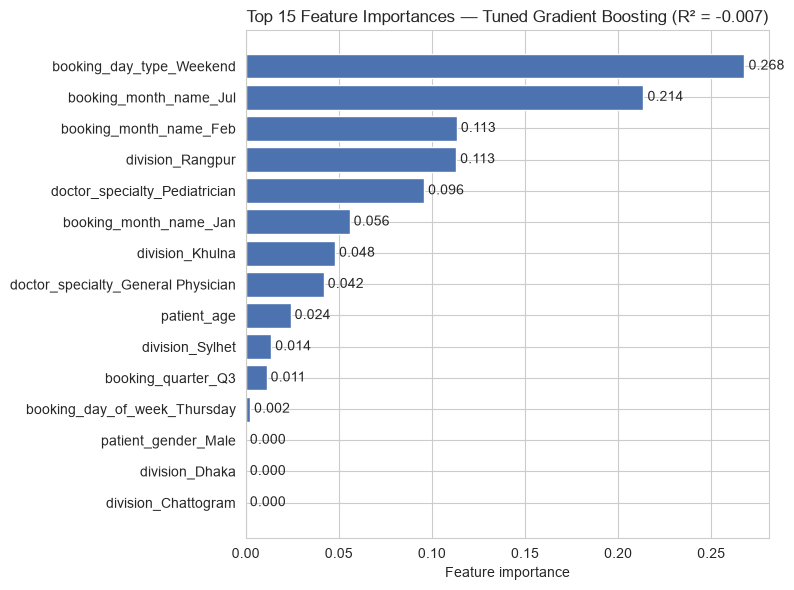

Best tuned model overall: Gradient Boosting (R² = -0.0073)


In [28]:
feature_names = gb_tuned.named_steps['preprocessor'].get_feature_names_out()
feature_names = [f.replace('cat__', '').replace('num__', '') for f in feature_names]
importances = gb_tuned.named_steps['regressor'].feature_importances_

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
imp_df_plot = imp_df.sort_values('importance')
bars = ax.barh(imp_df_plot['feature'], imp_df_plot['importance'], color='#4C72B0')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xlabel('Feature importance')
ax.set_title(f'Top 15 Feature Importances — Tuned Gradient Boosting (R² = {r2_gb_tuned:.3f})')
plt.tight_layout()
plt.show()

print(f"Best tuned model overall: Gradient Boosting (R² = {r2_gb_tuned:.4f})")

## Limitations

* **Limited predictive signal:** Every model, including the tuned versions, produced a negative R² compared with the naive "always predict the mean" baseline. This indicates that the available features did not provide enough information to reliably predict variation in `wait_days`.

* **Small dataset:** The dataset contains only 500 appointments, split into 400 training and 100 test records. With `wait_days` spread across roughly 1–20 days (std ≈ 5.9), the relatively small test set limits the ability to detect subtle relationships and make performance estimates less stable.

* **Missing operationally relevant features:** In real scheduling systems, waiting time can be influenced by factors such as clinic or doctor capacity, existing appointment backlog, appointment type or urgency, and available time slots. These operational factors are not present in the dataset. Patient demographics and calendar-based booking information alone may therefore be insufficient for predicting waiting time.
  
* **Further validation needed:** A larger dataset and additional validation would be needed before using the model for real-world healthcare decisions.